In [1]:
# LAB 02B

In [2]:
# antes será necessário instalar:
# pip install scikit-learn ou
# !pip3 install scikit-learn ou
# pip install factor_analyser
# !pip3 install factor_analyser

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [4]:
# Carga do conjunto de dados
# trocar o meu caminho onde salvei este arquivo pelo de vocês
#
dados_marketing = pd.read_csv("C:\\Users\\enggi\\Workspace\\ALGORITMOS_IA\\CURSO_IA\\ADEC_ANALISE_DADOS_BALBINOT\\DADOS\\Marketing01.csv")

In [5]:
dados_marketing = dados_marketing[['MntWines','MntFruits', 'MntMeatProducts', 'MntFishProducts', 
                                   'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 
                                   'NumWebPurchases','NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth']]

In [6]:
dados_marketing.head()

,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth
0,635,88,546,172,88,88,3,8,10,4,7
1,11,1,6,2,1,6,2,1,1,2,5
2,426,49,127,111,21,42,1,8,2,10,4
3,11,4,20,10,3,5,2,2,0,4,6
4,173,43,118,46,27,15,5,5,3,6,5


In [7]:
dados_marketing.shape

(2240, 11)

In [8]:
dados_marketing.dtypes

MntWines               int64
MntFruits              int64
MntMeatProducts        int64
MntFishProducts        int64
MntSweetProducts       int64
MntGoldProds           int64
NumDealsPurchases      int64
NumWebPurchases        int64
NumCatalogPurchases    int64
NumStorePurchases      int64
NumWebVisitsMonth      int64
dtype: object

In [9]:
dados_marketing.isnull().sum()

MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
dtype: int64

In [10]:
dados_marketing.dropna(inplace=True)

In [11]:
dados_marketing.shape

(2240, 11)

In [12]:
normalizar = StandardScaler()
dados_marketing_normalizados = normalizar.fit_transform(dados_marketing)

In [13]:
kmeans = KMeans(n_clusters= 4, init='k-means++',random_state= 1)
kmeans.fit(dados_marketing_normalizados)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",4
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",1
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [14]:
rotulo = kmeans.fit_predict(dados_marketing_normalizados)
dados_marketing_teste = dados_marketing.copy()
dados_marketing_teste['label'] = rotulo
dados_marketing_teste['label'] = dados_marketing_teste['label'].astype(str)

<Axes: xlabel='MntWines', ylabel='MntFruits'>

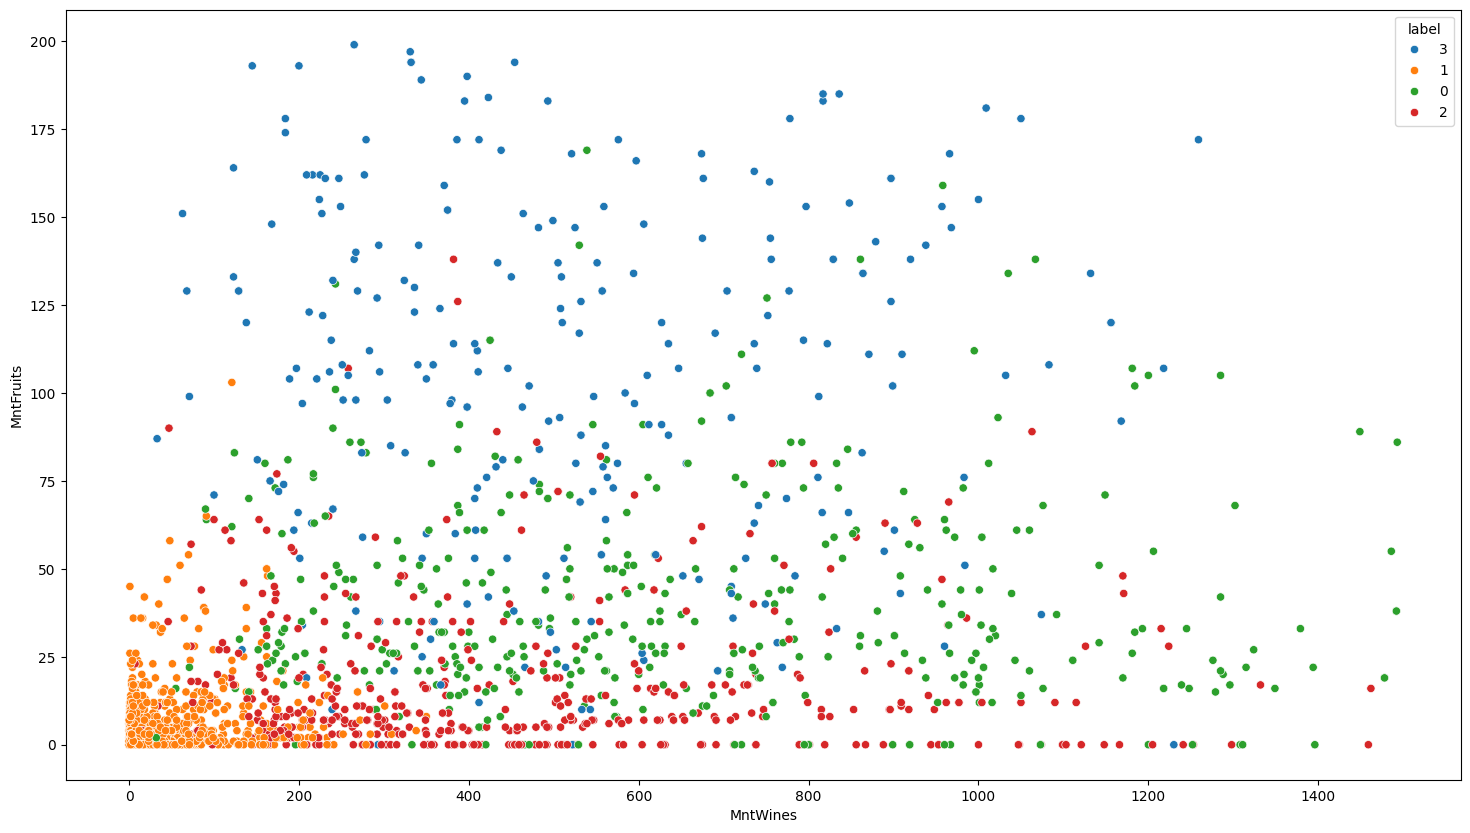

In [15]:
plt.figure(figsize= (18,10))
sns.scatterplot(x= dados_marketing_teste['MntWines'], y= dados_marketing_teste['MntFruits'], 
                hue = dados_marketing_teste['label'])

In [16]:
# Consultar também:
# https://www.analyticsvidhya.com/blog/2019/08/comprehensive-guide-k-means-clustering/
# https://www.freecodecamp.org/news/8-clustering-algorithms-in-machine-learning-that-all-data-scientists-should-know/

In [17]:
#

In [18]:
# Escolhendo o número ótimo de clusters para o algoritmo K-means

In [19]:
kmeans = KMeans(n_clusters= 4, init='k-means++',random_state = 1)
kmeans.fit(dados_marketing_normalizados)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",4
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",1
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [20]:
label = kmeans.fit_predict(dados_marketing_normalizados)

In [21]:
dados_marketing_teste = dados_marketing.copy()
dados_marketing_teste['cluster'] = rotulo
dados_marketing_teste['cluster'].value_counts()

cluster
1    1048
2     493
0     421
3     278
Name: count, dtype: int64

Text(0, 0.5, 'Inércia')

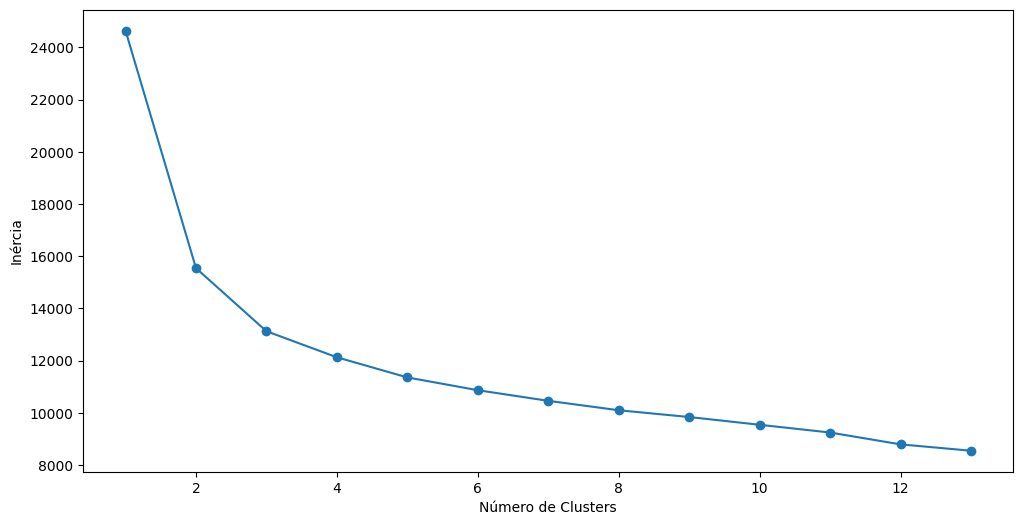

In [22]:
valor_distancia = []
for cluster in range(1,14):
    kmeans = KMeans(n_clusters = cluster, init='k-means++')
    kmeans.fit(dados_marketing_normalizados)
    valor_distancia.append(kmeans.inertia_)
saida_cluster = pd.DataFrame({'Cluster':range(1,14), 'distance_values': valor_distancia})
plt.figure(figsize=(12,6))
plt.plot(saida_cluster['Cluster'], saida_cluster['distance_values'], marker='o')
plt.xlabel('Número de Clusters')
plt.ylabel('Inércia')

In [23]:
#

In [24]:
# Perfilando clusters K-means

In [25]:
dados_marketing.head()

,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth
0,635,88,546,172,88,88,3,8,10,4,7
1,11,1,6,2,1,6,2,1,1,2,5
2,426,49,127,111,21,42,1,8,2,10,4
3,11,4,20,10,3,5,2,2,0,4,6
4,173,43,118,46,27,15,5,5,3,6,5


In [26]:
dados_marketing.dtypes

MntWines               int64
MntFruits              int64
MntMeatProducts        int64
MntFishProducts        int64
MntSweetProducts       int64
MntGoldProds           int64
NumDealsPurchases      int64
NumWebPurchases        int64
NumCatalogPurchases    int64
NumStorePurchases      int64
NumWebVisitsMonth      int64
dtype: object

In [27]:
normalizar = StandardScaler()
dados_marketing_normalizados = normalizar.fit_transform(dados_marketing)

In [28]:
kmeans = KMeans(n_clusters= 4, init='k-means++',random_state= 1)
kmeans.fit(dados_marketing_normalizados)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",4
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",1
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [29]:
rotulo = kmeans.fit_predict(dados_marketing_normalizados)
saida_dados_marketing = dados_marketing.copy()
saida_dados_marketing['cluster'] = rotulo
saida_dados_marketing['cluster'].value_counts()

cluster
1    1048
2     493
0     421
3     278
Name: count, dtype: int64

In [30]:
colunas  =['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts',
       'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases',
       'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
       'NumWebVisitsMonth']

In [31]:
media_global = saida_dados_marketing[colunas].apply(np.mean).T
media_global = pd.DataFrame(media_global,columns =['média global'])
media_global

,média global
MntWines,303.935714
MntFruits,26.302232
MntMeatProducts,166.950000
MntFishProducts,37.525446
MntSweetProducts,27.062946
MntGoldProds,44.021875
NumDealsPurchases,2.325000
NumWebPurchases,4.084821
NumCatalogPurchases,2.662054
NumStorePurchases,5.790179


In [32]:
media_cluster = saida_dados_marketing.groupby('cluster')[colunas].mean().T
media_cluster

cluster,0,1,2,3
MntWines,638.244656,43.962786,452.217039,514.744604
MntFruits,39.729216,5.224237,16.782961,102.309353
MntMeatProducts,416.928741,22.745229,120.651116,414.111511
MntFishProducts,71.420428,7.441794,22.632860,126.014388
MntSweetProducts,40.560570,5.287214,18.225152,104.384892
MntGoldProds,61.133017,15.206107,60.582150,97.370504
NumDealsPurchases,1.460808,1.903626,4.411765,1.521583
NumWebPurchases,5.004751,2.085878,6.553753,5.848921
NumCatalogPurchases,5.983373,0.581107,2.718053,5.377698
NumStorePurchases,8.581948,3.286260,7.271805,8.374101


In [33]:
pd.concat([media_cluster, media_global],axis =1)

,0,1,2,3,média global
MntWines,638.244656,43.962786,452.217039,514.744604,303.935714
MntFruits,39.729216,5.224237,16.782961,102.309353,26.302232
MntMeatProducts,416.928741,22.745229,120.651116,414.111511,166.950000
MntFishProducts,71.420428,7.441794,22.632860,126.014388,37.525446
MntSweetProducts,40.560570,5.287214,18.225152,104.384892,27.062946
MntGoldProds,61.133017,15.206107,60.582150,97.370504,44.021875
NumDealsPurchases,1.460808,1.903626,4.411765,1.521583,2.325000
NumWebPurchases,5.004751,2.085878,6.553753,5.848921,4.084821
NumCatalogPurchases,5.983373,0.581107,2.718053,5.377698,2.662054
NumStorePurchases,8.581948,3.286260,7.271805,8.374101,5.790179


In [34]:
#

In [35]:
# PCA - Análise do Componente Principal

In [36]:
import numpy as np
import pylab as pl

In [37]:
x = [-2.5, -0.5, -2.2, -1.9, -3.1, -2.3, -2, -1, -1.5, -1.1]
y = [2.4, 0.7, 2.9, 2.2, 3.0, 2.7, 1.6, 1.1, 1.6, 0.9]

In [38]:
print ('X: ', x)
print ('Y: ', y)

X:  [-2.5, -0.5, -2.2, -1.9, -3.1, -2.3, -2, -1, -1.5, -1.1]
Y:  [2.4, 0.7, 2.9, 2.2, 3.0, 2.7, 1.6, 1.1, 1.6, 0.9]


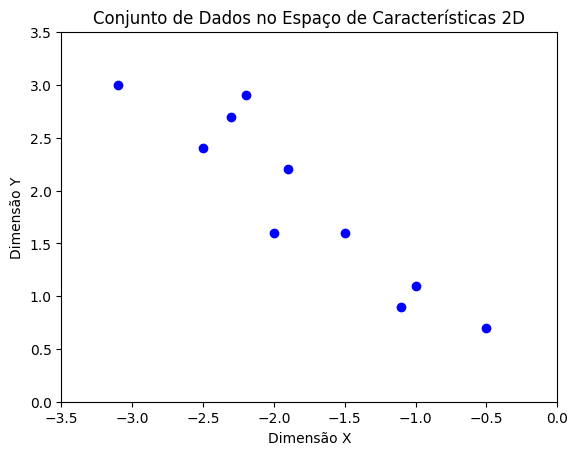

In [39]:
pl.title ('Conjunto de Dados no Espaço de Características 2D')
pl.xlabel ('Dimensão X')
pl.ylabel ('Dimensão Y')
pl.xlim (-3.5, 0.0)
pl.ylim (0.0, 3.5)
pl.plot(x, y, 'bo')
pl.show()

In [40]:
mediaX = np.mean(x)
mediaY = np.mean(y)
print('Média de X:', mediaX)
print('Média de Y:', mediaY)

Média de X: -1.81
Média de Y: 1.9100000000000001


In [41]:
x1 = x - np.mean(x)
y1 = y - np.mean(y)
print ('X - Média(X):', x1)
print ('Y - Média(Y):', y1)

X - Média(X): [-0.69  1.31 -0.39 -0.09 -1.29 -0.49 -0.19  0.81  0.31  0.71]
Y - Média(Y): [ 0.49 -1.21  0.99  0.29  1.09  0.79 -0.31 -0.81 -0.31 -1.01]


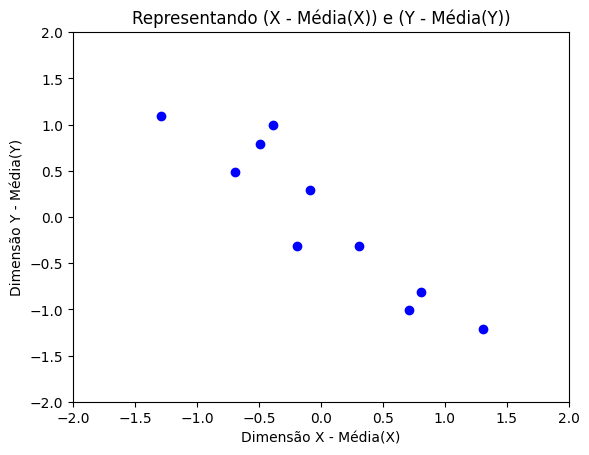

In [42]:
pl.title ('Representando (X - Média(X)) e (Y - Média(Y))')
pl.xlabel ('Dimensão X - Média(X)')
pl.ylabel ('Dimensão Y - Média(Y)')
pl.xlim (-2.0, 2.0)
pl.ylim (-2.0, 2.0)
pl.plot(x1, y1, 'bo')
pl.show()

In [43]:
import pandas as pd
m = np.array([x1, y1]).T
df = pd.DataFrame(m, index=[i for i in range(1,len(x1)+1)], columns=['x1', 'y1'])
print(df)

      x1    y1
1  -0.69  0.49
2   1.31 -1.21
3  -0.39  0.99
4  -0.09  0.29
5  -1.29  1.09
6  -0.49  0.79
7  -0.19 -0.31
8   0.81 -0.81
9   0.31 -0.31
10  0.71 -1.01


In [44]:
covMatriz = np.cov(m.T)
df = pd.DataFrame(covMatriz, index=['x', 'y'], columns = ['x', 'y'])
print(df)

          x         y
x  0.616556 -0.615444
y -0.615444  0.716556


In [45]:
# Utilizando a matriz de covariância obtida no passo 2), obtemos os seguintes autovalores:

In [46]:
autovalores, autovetores = np.linalg.eig(covMatriz)
print ('Autovalores: ')
for i in range(len(autovalores)):
    print('lambda', i+1, ': ', autovalores[i])

Autovalores: 
lambda 1 :  0.04908339893832736
lambda 2 :  1.2840277121727839


In [47]:
print("Autovetores")
df =pd.DataFrame(autovetores, index=['1', '2'], columns=['x1', 'x2'])
print(df)

Autovetores
         x1        x2
1 -0.735179  0.677873
2 -0.677873 -0.735179


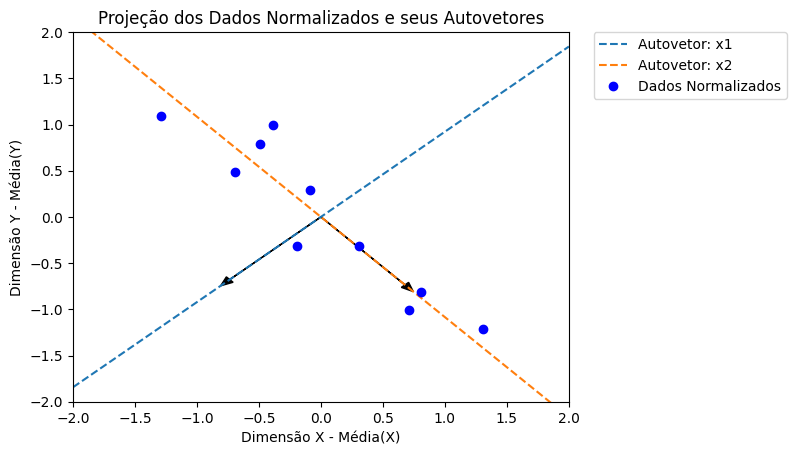

In [48]:
x = [i for i in range(-2, 3)]
autovetor1 =[autovetores[1][0]*i/autovetores[0][0] for i in x]
autovetor2 =[autovetores[1][1]*i/autovetores[0][1] for i in x]
pl.arrow(0, 0, autovetores[0][0], autovetores[1][0], head_width=0.08, head_length=0.1, fc='k', ec='k')
pl.arrow(0, 0, autovetores[0][1], autovetores[1][1], head_width=0.08, head_length=0.1, fc='k', ec='k')
pl.plot(x, autovetor1, linestyle='--', label='Autovetor: x1')
pl.plot(x, autovetor2, linestyle='--', label='Autovetor: x2')
pl.plot(x1, y1, 'bo', label='Dados Normalizados')
pl.title('Projeção dos Dados Normalizados e seus Autovetores')
pl.xlabel('Dimensão X - Média(X)')
pl.ylabel('Dimensão Y - Média(Y)')
pl.xlim([-2,2])
pl.ylim([-2,2])
pl.legend(bbox_to_anchor=(1.05, 1), loc =2, borderaxespad=0.)
pl.show()

In [49]:
idx = autovalores.argsort()[::-1]
print('Autovalores ordenados por ordem decrescente:')
for i in idx:
    print('lambda', i+1, ':', autovalores[i])

Autovalores ordenados por ordem decrescente:
lambda 2 : 1.2840277121727839
lambda 1 : 0.04908339893832736


In [50]:
print ('Autovetores ordenados por ordem descrecente:')
sortedAutovetores = autovetores[:, idx]
df = pd.DataFrame(sortedAutovetores, index=['1', '2'], columns = ['x2', 'x1'])
print (df)

Autovetores ordenados por ordem descrecente:
         x2        x1
1  0.677873 -0.735179
2 -0.735179 -0.677873


In [51]:
print("Vetor de Características: F")
f = autovetores[:,idx]
df = pd.DataFrame(sortedAutovetores, index=['1', '2'], columns=['v2', 'v1'])
print(df)

Vetor de Características: F
         v2        v1
1  0.677873 -0.735179
2 -0.735179 -0.677873


In [52]:
print('Conjunto de Dados Normalizado: M')
m = np.array([x1, y1]).T
df = pd.DataFrame(m, index=[i for i in range(1, len(x1)+1)], columns=['x1', 'y1'])
print(df)

Conjunto de Dados Normalizado: M
      x1    y1
1  -0.69  0.49
2   1.31 -1.21
3  -0.39  0.99
4  -0.09  0.29
5  -1.29  1.09
6  -0.49  0.79
7  -0.19 -0.31
8   0.81 -0.81
9   0.31 -0.31
10  0.71 -1.01


In [53]:
transposta_f = f.T
transposta_m = m.T
headers = [i for i in range (1, len(x1)+1)]
r = np.dot(transposta_f, transposta_m)
print("Dados Transformados: R")
df = pd.DataFrame(r, index=['x', 'y'], columns = headers)
print(df)

Dados Transformados: R
         1         2         3         4         5         6         7   \
x -0.827970  1.777580 -0.992197 -0.274210 -1.675801 -0.912949  0.099109   
y  0.175115 -0.142857 -0.384375 -0.130417  0.209498 -0.175282  0.349825   

         8         9         10  
x  1.144572  0.438046  1.223821  
y -0.046417 -0.017765  0.162675  


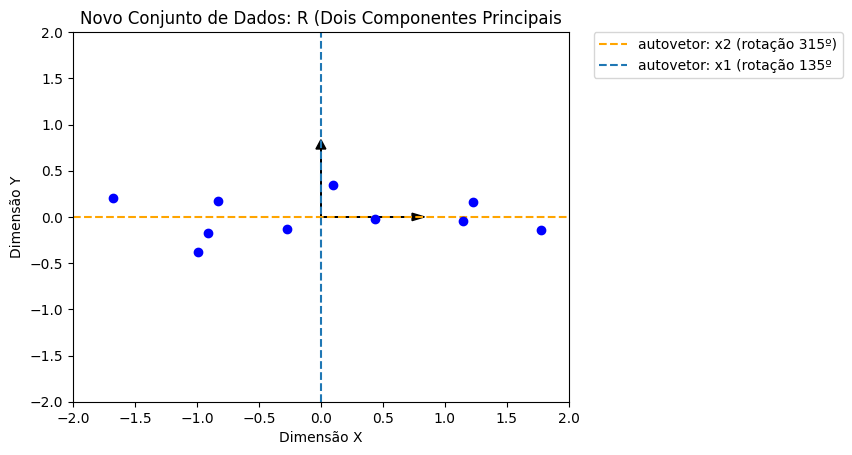

In [54]:
novo_x = r[0,]
novo_y = r[1,]
x= [i for i in range(-2,3)]
pl.arrow(0, 0, -autovetores[0][0], 0, head_width=0.08, head_length=0.1, fc='k', ec='k')
pl.arrow(0, 0, 0, -autovetores[1][1], head_width=0.08, head_length=0.1, fc='k', ec='k')
pl.axhline(0, linestyle='--', color='#FFA500', label='autovetor: x2 (rotação 315º)')
pl.axvline(0, linestyle='--', label='autovetor: x1 (rotação 135º')
pl.plot(novo_x, novo_y, 'bo')
pl.title('Novo Conjunto de Dados: R (Dois Componentes Principais')
pl.xlabel('Dimensão X')
pl.ylabel('Dimensão Y')
pl.xlim([-2.0,2.0])
pl.ylim([-2.0,2.0])
pl.legend(bbox_to_anchor=(1.05, 1), loc =2, borderaxespad=0.)
pl.show()

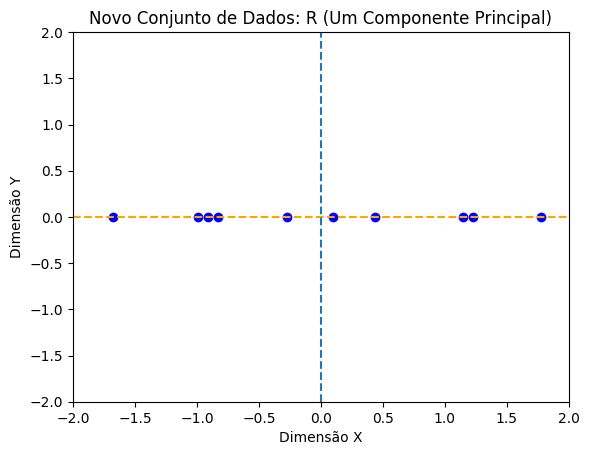

In [55]:
y= [0 for i in range(10)]
pl.plot(novo_x, y, 'bo')
pl.axhline(0, linestyle='--', color='#FFA500')
pl.axvline(0, linestyle='--')
pl.title('Novo Conjunto de Dados: R (Um Componente Principal)')
pl.xlabel('Dimensão X')
pl.ylabel('Dimensão Y')
pl.xlim([-2.0,2.0])
pl.ylim([-2.0,2.0])
pl.show()

In [56]:
f = transposta_f.T
headers = [i for i in range(1, len(x1)+1)]
original = np.dot(f, r)
original[0,]=original[0,]+mediaX
original[1,]=original[1,]+mediaY
print("Dados Original Recuperados: (Dois Componentes Principais)")
df = pd.DataFrame(original, index=['x', 'y'], columns=headers)
print(df)

Dados Original Recuperados: (Dois Componentes Principais)
    1    2    3    4    5    6    7    8    9    10
x -2.5 -0.5 -2.2 -1.9 -3.1 -2.3 -2.0 -1.0 -1.5 -1.1
y  2.4  0.7  2.9  2.2  3.0  2.7  1.6  1.1  1.6  0.9


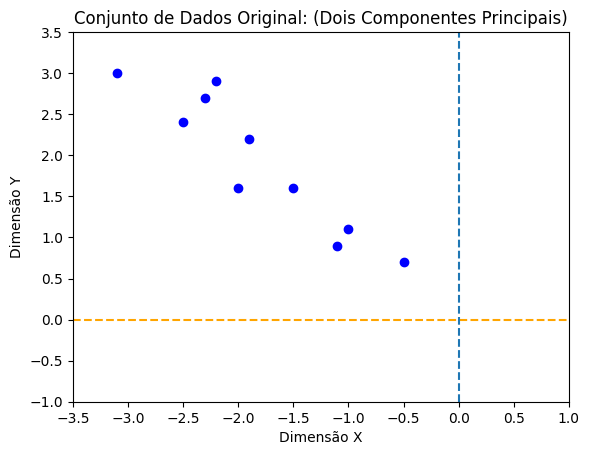

In [57]:
original_x = original[0,]
original_y = original[1,]
pl.axhline(0, linestyle='--', color='#FFA500')
pl.axvline(0, linestyle='--')
pl.plot(original_x, original_y, 'bo')
pl.title("Conjunto de Dados Original: (Dois Componentes Principais)")
pl.xlabel('Dimensão X')
pl.ylabel('Dimensão Y')
pl.xlim(-3.5, 1.0)
pl.ylim(-1.0, 3.5)
pl.show()

In [58]:
f_vetor1 = np.array([f[:,0]]).T
r_1_componente = np.array([r[0,]])
headers = [i for i in range(1, len(x1)+1)]
original_1_comp = np.dot(f_vetor1, r_1_componente)
original_1_comp[0,]=original_1_comp[0,]+mediaX
original_1_comp[1,]=original_1_comp[1,]+mediaY
print("Dados Originais Recuperados: ('Um Componente Principal')")
df - pd.DataFrame(original_1_comp, index=['x', 'y'], columns=headers)
print(df)

Dados Originais Recuperados: ('Um Componente Principal')
    1    2    3    4    5    6    7    8    9    10
x -2.5 -0.5 -2.2 -1.9 -3.1 -2.3 -2.0 -1.0 -1.5 -1.1
y  2.4  0.7  2.9  2.2  3.0  2.7  1.6  1.1  1.6  0.9


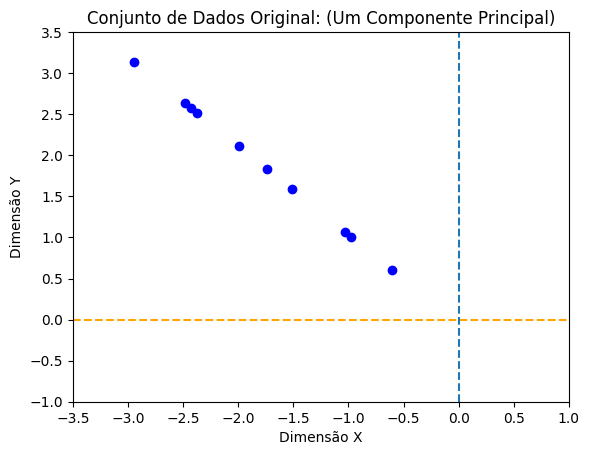

In [59]:
original_1_comp_x = original_1_comp[0,]
original_1_comp_y = original_1_comp[1,]
pl.axhline(0, linestyle='--', color='#FFA500')
pl.axvline(0, linestyle='--')
pl.plot(original_1_comp_x, original_1_comp_y, 'bo')
pl.title("Conjunto de Dados Original: (Um Componente Principal)")
pl.xlabel('Dimensão X')
pl.ylabel('Dimensão Y')
pl.xlim(-3.5, 1.0)
pl.ylim(-1.0, 3.5)
pl.show()

In [60]:
# Outro exemplo

In [61]:
import numpy as np
from scipy import linalg as la
dados=np.array([[7., 4., 3.],
               [4., 1., 8.],
               [6., 3., 5.],
               [8., 6., 1.],
               [8., 5., 7.],
               [7., 2., 9.],
               [5., 3., 3.],
               [9., 5., 8.],
               [7., 4., 5.],
               [8., 2., 2.]])

In [62]:
dados -= dados.mean(axis=0)
cov = np.cov(dados, rowvar=False)

In [63]:
autovalores, autovetores = la.eig(cov)
print("Autovalores:", autovalores)
print("Autovetores:", autovetores)

Autovalores: [0.74992815+0.j 3.67612927+0.j 8.27394258+0.j]
Autovetores: [[-0.70172743  0.69903712 -0.1375708 ]
 [ 0.70745703  0.66088917 -0.25045969]
 [ 0.08416157  0.27307986  0.95830278]]


In [64]:
num_componentes=2
classifica = np.argsort(autovalores)[::-1][:num_componentes]
autovalores, autovetores = autovalores[classifica], autovetores[:, classifica]
print("Valores dos Autovalores:", autovalores)
print("Valores dos Autovetores:", autovetores)

Valores dos Autovalores: [8.27394258+0.j 3.67612927+0.j]
Valores dos Autovetores: [[-0.1375708   0.69903712]
 [-0.25045969  0.66088917]
 [ 0.95830278  0.27307986]]


In [65]:
principal_componentes=np.dot(dados,autovetores)
print("Componentes Principais (PCA):", principal_componentes)

Componentes Principais (PCA): [[-2.15142276 -0.17311941]
 [ 3.80418259 -2.88749898]
 [ 0.15321328 -0.98688598]
 [-4.7065185   1.30153634]
 [ 1.29375788  2.27912632]
 [ 4.0993133   0.1435814 ]
 [-1.62582148 -2.23208282]
 [ 2.11448986  3.2512433 ]
 [-0.2348172   0.37304031]
 [-2.74637697 -1.06894049]]


In [66]:
# Mesmo exemplo simples anterior, mas usando o sklearn

In [67]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
data=np.array([[7., 4., 3.],
               [4., 1., 8.],
               [6., 3., 5.],
               [8., 6., 1.],
               [8., 5., 7.],
               [7., 2., 9.],
               [5., 3., 3.],
               [9., 5., 8.],
               [7., 4., 5.],
               [8., 2., 2.]])

In [68]:
pca_model = PCA(n_components=2)
components = pca_model.fit_transform(data)
df_componentes = pd.DataFrame(data = components, columns = ['Primeiro Componente Principal', 'Segundo Componente Principal'])
print(df_componentes)

   Primeiro Componente Principal  Segundo Componente Principal
0                      -2.151423                     -0.173119
1                       3.804183                     -2.887499
2                       0.153213                     -0.986886
3                      -4.706518                      1.301536
4                       1.293758                      2.279126
5                       4.099313                      0.143581
6                      -1.625821                     -2.232083
7                       2.114490                      3.251243
8                      -0.234817                      0.373040
9                      -2.746377                     -1.068940


In [69]:
#

In [70]:
# aplicando PCA na base de dados flor de íris

In [71]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
iris = sns.load_dataset("iris")
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [72]:
iris.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [73]:
X = iris.iloc[:,0:4]
Y = iris.iloc[:,4]
iris_std = (X-X.mean())/X.std()
iris_std = pd.concat([iris_std,Y],axis=1)
iris_std.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,-0.897674,1.015602,-1.335752,-1.311052,setosa
1,-1.139200,-0.131539,-1.335752,-1.311052,setosa
2,-1.380727,0.327318,-1.392399,-1.311052,setosa
3,-1.501490,0.097889,-1.279104,-1.311052,setosa
4,-1.018437,1.245030,-1.335752,-1.311052,setosa


In [74]:
iris_std.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,1.500000e+02,1.500000e+02,1.500000e+02,1.500000e+02
mean,-5.684342e-16,-7.815970e-16,-2.842171e-16,-3.789561e-16
std,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
min,-1.863780e+00,-2.425820e+00,-1.562342e+00,-1.442245e+00
25%,-8.976739e-01,-5.903951e-01,-1.222456e+00,-1.179859e+00
50%,-5.233076e-02,-1.315388e-01,3.353541e-01,1.320673e-01
75%,6.722490e-01,5.567457e-01,7.602115e-01,7.880307e-01
max,2.483699e+00,3.080455e+00,1.779869e+00,1.706379e+00


C:\Users\enggi\AppData\Local\Temp\ipykernel_7144\3760681448.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  axes_0= sns.distplot(iris['sepal_length'],kde = True, hist=True,color='black',ax=axes[0,0])
C:\Users\enggi\AppData\Local\Temp\ipykernel_7144\3760681448.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  axes_1

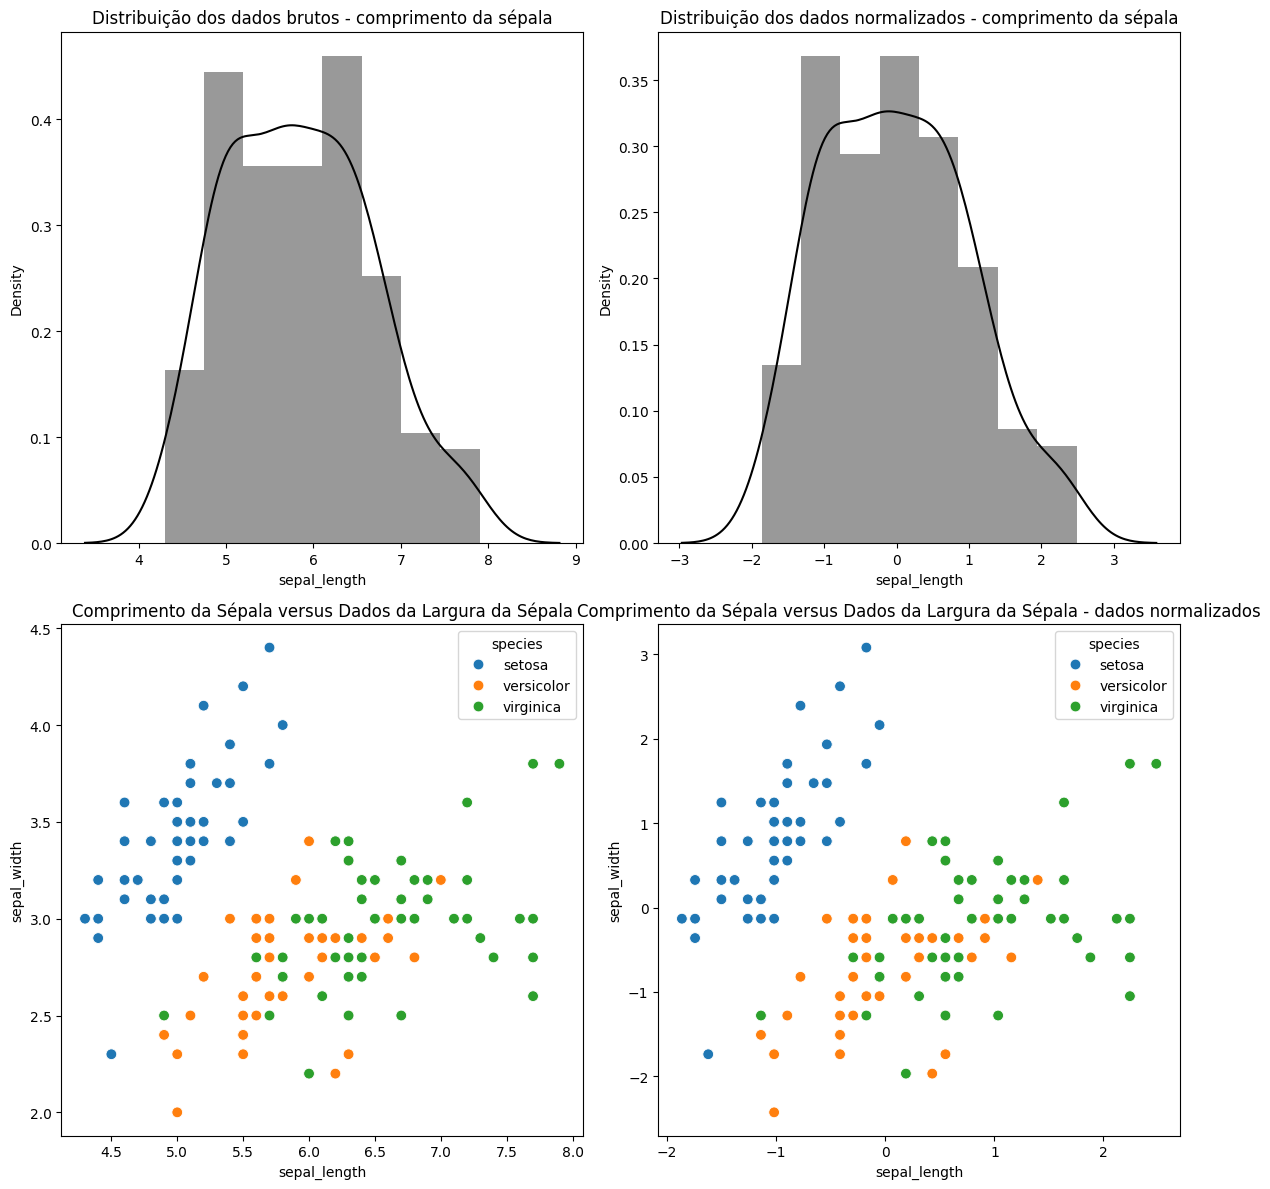

In [75]:
fig, axes = plt.subplots(nrows=2, ncols=2,figsize=(12,12))
axes_0= sns.distplot(iris['sepal_length'],kde = True, hist=True,color='black',ax=axes[0,0])
axes_0.set_title('Distribuição dos dados brutos - comprimento da sépala')
axes_1 = sns.distplot(iris_std['sepal_length'],kde = True, hist=True,color='black',ax=axes[0,1])
axes_1.set_title('Distribuição dos dados normalizados - comprimento da sépala')
axes_2 = sns.scatterplot(x='sepal_length',y='sepal_width', data = iris,hue='species',s=60,ax=axes[1,0])
axes_2.set_title('Comprimento da Sépala versus Dados da Largura da Sépala')
axes_3 = sns.scatterplot(x='sepal_length',y='sepal_width', data = iris_std,s=60,hue='species',ax=axes[1,1])
axes_3.set_title('Comprimento da Sépala versus Dados da Largura da Sépala - dados normalizados')
plt.tight_layout()
plt.show()

In [76]:
x_std = iris_std.iloc[:,:4].values 
y = iris_std.iloc[:,4].values 
cor_mat = np.corrcoef(x_std.T)
autovalores, autovetores = np.linalg.eig(cor_mat)
print('Matriz de Correlação \n{}'.format(cor_mat))
print('\nAutovetores \n{}'.format(autovetores))
print('\nAutovalores \n{}'.format(autovalores))

Matriz de Correlação 
[[ 1.         -0.11756978  0.87175378  0.81794113]
 [-0.11756978  1.         -0.4284401  -0.36612593]
 [ 0.87175378 -0.4284401   1.          0.96286543]
 [ 0.81794113 -0.36612593  0.96286543  1.        ]]

Autovetores 
[[ 0.52106591 -0.37741762 -0.71956635  0.26128628]
 [-0.26934744 -0.92329566  0.24438178 -0.12350962]
 [ 0.5804131  -0.02449161  0.14212637 -0.80144925]
 [ 0.56485654 -0.06694199  0.63427274  0.52359713]]

Autovalores 
[2.91849782 0.91403047 0.14675688 0.02071484]


In [77]:
u,s,v = np.linalg.svd(cor_mat)
print("Autovetores \n{}".format(u))
print("\nAutovalores \n{}".format(s))

Autovetores 
[[-0.52106591 -0.37741762  0.71956635  0.26128628]
 [ 0.26934744 -0.92329566 -0.24438178 -0.12350962]
 [-0.5804131  -0.02449161 -0.14212637 -0.80144925]
 [-0.56485654 -0.06694199 -0.63427274  0.52359713]]

Autovalores 
[2.91849782 0.91403047 0.14675688 0.02071484]


In [78]:
pares = [(np.abs(autovalores[i]), autovetores[:,i]) for i in range(len (autovalores))]
pares.sort()
pares.reverse()
print("\nPares de Autovalores e Autovetores em Ordem Decrescente:")
for i in pares:
    print(i)


Pares de Autovalores e Autovetores em Ordem Decrescente:
(np.float64(2.9184978165319952), array([ 0.52106591, -0.26934744,  0.5804131 ,  0.56485654]))
(np.float64(0.914030471468069), array([-0.37741762, -0.92329566, -0.02449161, -0.06694199]))
(np.float64(0.146756875571315), array([-0.71956635,  0.24438178,  0.14212637,  0.63427274]))
(np.float64(0.0207148364286193), array([ 0.26128628, -0.12350962, -0.80144925,  0.52359713]))


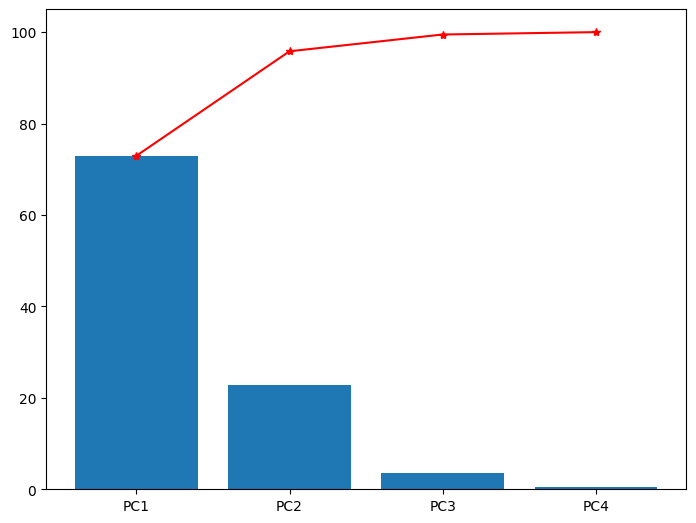

In [79]:
total = sum(autovalores)
var_exp = [(i / total)*100 for i in sorted(autovalores, reverse=True)]
var_cum_exp = np.cumsum(var_exp)
fig = plt.figure()
ax = fig.add_axes([0,0,1,1])
PC = ['PC1', 'PC2', 'PC3', 'PC4']
plot = ax.bar(PC,var_exp)
ax.plot(var_cum_exp,'r*-')
def autolabel(plot):
    for rect in plot:
        height = rect.get_height()
        ax.annotate('{}'.format(round(height,2)),xy=(rect.get_x() + rect.get_width() / 2, height),xytext=(0, 3), 
                    textcoords="offset points",ha='center', va='bottom')
        plt.ylabel('Variância Preservada')
        autolabel(plot)
plt.show()

In [80]:
matriz_w = np.hstack((pares[0][1].reshape(4,1),
pares[1][1].reshape(4,1)))
print('Matriz W:\n', matriz_w)

Matriz W:
 [[ 0.52106591 -0.37741762]
 [-0.26934744 -0.92329566]
 [ 0.5804131  -0.02449161]
 [ 0.56485654 -0.06694199]]


In [81]:
características= iris.iloc[:,0:4].values
iris_transform = características.dot(matriz_w)
iris_transform = pd.DataFrame(iris_transform,columns = ['PC1','PC2'])
iris_transform = pd.concat([iris_transform,Y],axis=1)
iris_transform.head()

,PC1,PC2,species
0,2.640270,-5.204041,setosa
1,2.670730,-4.666910,setosa
2,2.454606,-4.773636,setosa
3,2.545517,-4.648463,setosa
4,2.561228,-5.258629,setosa


<Axes: xlabel='PC1', ylabel='PC2'>

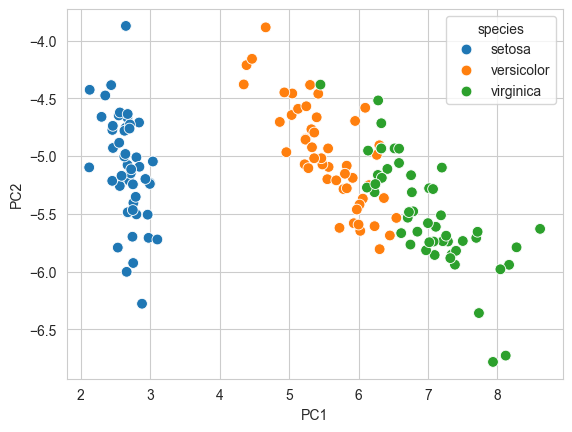

In [82]:
sns.set_style("whitegrid")
sns.scatterplot(x = 'PC1',y = 'PC2',data = iris_transform,hue = 'species',s = 60)

In [83]:
# PCA com a biblioteca PCA com a base de dados flor de íris

In [84]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
iris = sns.load_dataset("iris")
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [85]:
iris.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [86]:
X = iris.iloc[:,0:4]
Y = iris.iloc[:,4]
# normalização
iris_std = (X-X.mean())/X.std()
iris_std = pd.concat([iris_std,Y],axis=1)
iris_std.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,-0.897674,1.015602,-1.335752,-1.311052,setosa
1,-1.139200,-0.131539,-1.335752,-1.311052,setosa
2,-1.380727,0.327318,-1.392399,-1.311052,setosa
3,-1.501490,0.097889,-1.279104,-1.311052,setosa
4,-1.018437,1.245030,-1.335752,-1.311052,setosa


In [87]:
iris_std.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,1.500000e+02,1.500000e+02,1.500000e+02,1.500000e+02
mean,-5.684342e-16,-7.815970e-16,-2.842171e-16,-3.789561e-16
std,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
min,-1.863780e+00,-2.425820e+00,-1.562342e+00,-1.442245e+00
25%,-8.976739e-01,-5.903951e-01,-1.222456e+00,-1.179859e+00
50%,-5.233076e-02,-1.315388e-01,3.353541e-01,1.320673e-01
75%,6.722490e-01,5.567457e-01,7.602115e-01,7.880307e-01
max,2.483699e+00,3.080455e+00,1.779869e+00,1.706379e+00


C:\Users\enggi\AppData\Local\Temp\ipykernel_7144\3760681448.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  axes_0= sns.distplot(iris['sepal_length'],kde = True, hist=True,color='black',ax=axes[0,0])
C:\Users\enggi\AppData\Local\Temp\ipykernel_7144\3760681448.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  axes_1

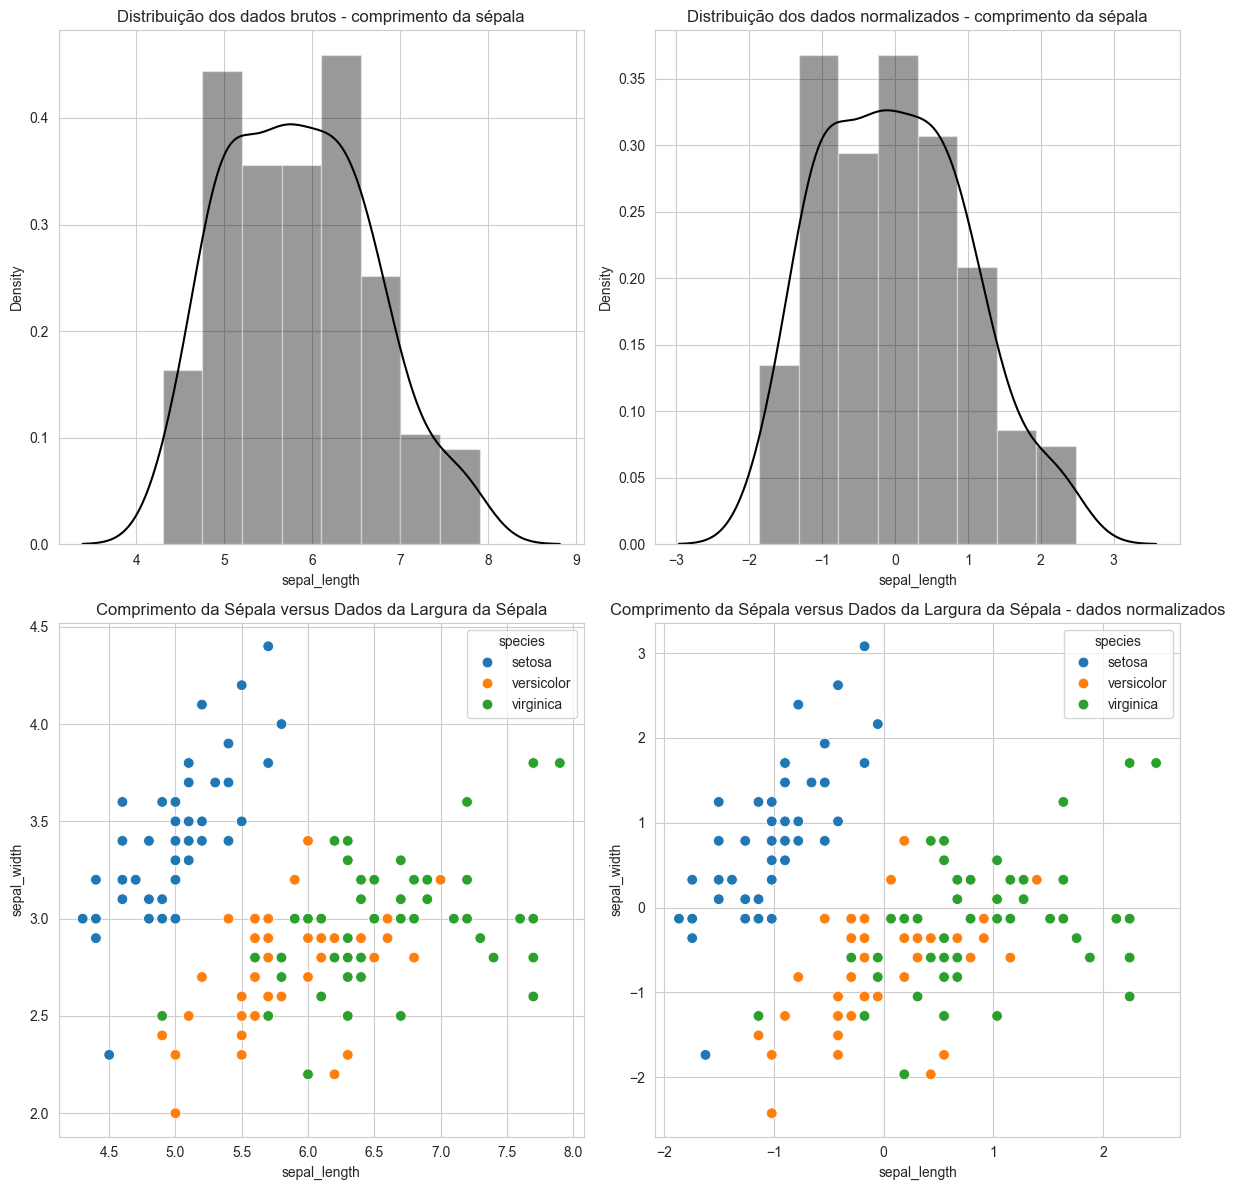

In [88]:
fig, axes = plt.subplots(nrows=2, ncols=2,figsize=(12,12))
axes_0= sns.distplot(iris['sepal_length'],kde = True, hist=True,color='black',ax=axes[0,0])
axes_0.set_title('Distribuição dos dados brutos - comprimento da sépala')
axes_1 = sns.distplot(iris_std['sepal_length'],kde = True, hist=True,color='black',ax=axes[0,1])
axes_1.set_title('Distribuição dos dados normalizados - comprimento da sépala')
axes_2 = sns.scatterplot(x='sepal_length',y='sepal_width', data = iris,hue='species',s=60,ax=axes[1,0])
axes_2.set_title('Comprimento da Sépala versus Dados da Largura da Sépala')
axes_3 = sns.scatterplot(x='sepal_length',y='sepal_width', data = iris_std,s=60,hue='species',ax=axes[1,1])
axes_3.set_title('Comprimento da Sépala versus Dados da Largura da Sépala - dados normalizados')
plt.tight_layout()
plt.show()

In [89]:
x_std = iris_std.iloc[:,:4].values # características
y = iris_std.iloc[:,4].values # rótulos

In [90]:
from sklearn.decomposition import PCA
sklearn_pca = PCA(n_components=2)
print(x_std.shape)
PCs = sklearn_pca.fit_transform(x_std)
print(PCs.shape)

(150, 4)
(150, 2)


<Axes: xlabel='PC1', ylabel='PC2'>

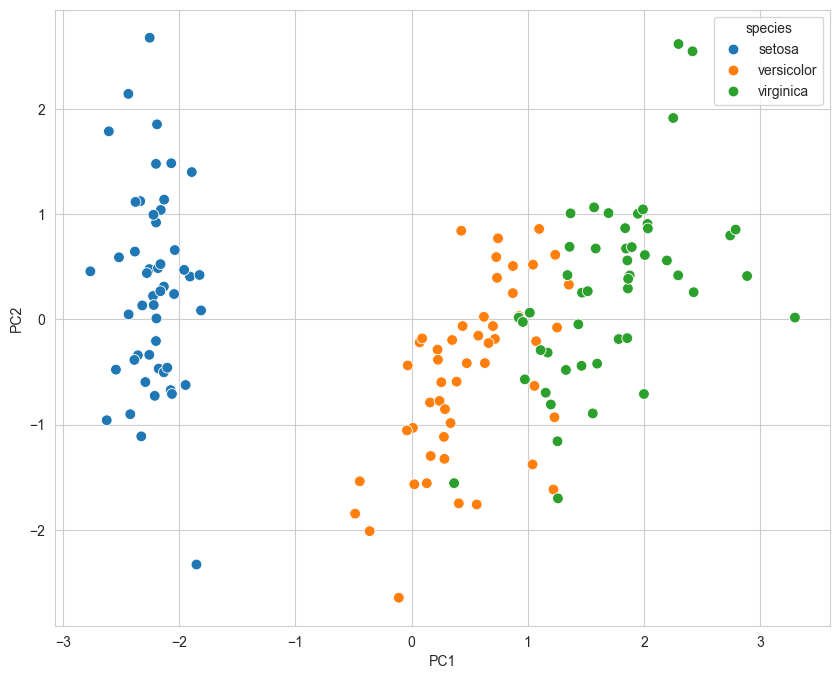

In [91]:
iris_transform = pd.DataFrame(PCs,columns=['PC1','PC2'])
iris_transform = pd.concat([iris_transform,Y],axis=1)
fig, axes = plt.subplots(figsize=(10,8))
sns.set_style("whitegrid")
sns.scatterplot(x='PC1',y='PC2',data = iris_transform,hue='species',s=60)

In [92]:
sklearn_pca.explained_variance_ratio_

array([0.72962445, 0.22850762])

In [93]:
# PCA com a biblioteca PCA com a base de vinho.data

In [94]:
import pandas as pd
df_vinho = pd.read_csv('C:/Users/abalb/Desktop/vinho.data', header=None)

FileNotFoundError: [Errno 2] No such file or directory: 'C:/Users/abalb/Desktop/vinho.data'

In [ ]:
from sklearn.model_selection import train_test_split
X, y = df_vinho.iloc[:, 1:].values, df_vinho.iloc[:, 0].values
X_trein, X_teste, y_trein, y_teste = train_test_split(X, y, test_size=0.3,stratify=y,random_state=0)
from sklearn.preprocessing import StandardScaler
normaliza = StandardScaler()
X_trein_std = normaliza.fit_transform(X_trein)
X_teste_std = normaliza.transform(X_teste)

In [ ]:
import numpy as np
matriz_cov = np.cov(X_trein_std.T)
autovalores, autovetores = np.linalg.eig(matriz_cov)
print('\nAutovalores\n%s' % autovalores)

In [ ]:
total = sum(autovalores)
var_exp = [(i / total) for i in sorted(autovalores, reverse=True)]
var_cum_exp = np.cumsum(var_exp)
import matplotlib.pyplot as plt
plt.bar(range(1,14), var_exp, alpha=0.5, align='center', label='Variância Individual')
plt.step(range(1,14), var_cum_exp, where='mid', label='Variância Cumulativa')
plt.ylabel('Razão da Variância')
plt.xlabel('Índice do Componente Principal')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

In [ ]:
pares = [(np.abs(autovalores[i]), autovetores[:, i]) for i in range(len(autovalores))]
pares.sort(key =lambda k:k[0], reverse=True)

In [ ]:
w = np.hstack((pares[0][1][:, np.newaxis], pares[1][1][:, np.newaxis]))
print('Matriz W:\n', w)

In [ ]:
X_trein_std[0].dot(w)

In [ ]:
X_trein_pca = X_trein_std.dot(w)

In [ ]:
colors = ['r', 'b', 'g']
markers = ['s', 'x', 'o']
for l, c, m in zip(np.unique(y_trein), colors, markers): 
    plt.scatter(X_trein_pca[y_trein==l, 0],X_trein_pca[y_trein==l, 1],c=c, label=l, marker=m)
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

In [ ]:
# PCA - Análise do Componente Principal

In [ ]:
from sklearn.decomposition import PCA

In [ ]:
pca_marketing = PCA(n_components=6,random_state = 1)
ComponentesPrincipais_marketing = pca_marketing.fit_transform(dados_marketing_normalizados)

In [ ]:
dados_principal_marketing = pd.DataFrame(data = ComponentesPrincipais_marketing, 
                                         columns = ['principal component 1', 'principal component 2',
                                                    'principal component 3','principal component 4',
                                                    'principal component 5','principal component 6'])
dados_principal_marketing

In [ ]:
# Escolhendo o número de componentes principais

In [ ]:
for i in range(0,len(pca_marketing.explained_variance_ratio_)):
    print("Componente ",i ," ",pca_marketing.explained_variance_ratio_[i])

In [ ]:
plt.figure(figsize= (12,6))

PC_values = np.arange(pca_marketing.n_components_) + 1
cummulative_variance = np.cumsum(pca_marketing.explained_variance_ratio_)
plt.plot(PC_values, cummulative_variance, 'o-', linewidth=2, color='blue')
plt.title('Scree Plot: apresenta os autovalores do PCA')
plt.xlabel('Componentes Principais')
plt.ylabel('Variância Explicada Cummulativa')
plt.show()

In [ ]:
# Analisando os Componentes Principais

In [ ]:
loadings_df = pd.DataFrame(pca_marketing.components_).T
loadings_df = loadings_df.set_index(dados_marketing.columns)
loadings_df

In [ ]:
loadings_df.where(abs(loadings_df) >= 0.35)

In [ ]:
# Deixo como sugestão a consulta ao método factor analysis - também pode ser usado para redução da dimensionalidade